# [Trajectory Analysis] Figure 5

## The amount of information available to the mouse correlates inversely with infotaxis behavior. 

In [1]:
cd "/app/"

/app


In [2]:
%run env.py
%run run.py connect

/opt/conda/lib/python3.11/site-packages/datajoint/settings.py:1039: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from vr4mice.analysis.analysis import style
from vr4mice.schema import vr4mice
from vr4mice.analysis import utils, plotting, analysis
from vr4mice.schema.vr4mice import Groups, Labels
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, MeanVelocities
from vr4mice.analysis.stats import get_multi_p_values_binned, get_multi_p_values_global, plot_aperture_heatmap
from statsmodels.stats.anova import AnovaRM
import statsmodels.formula.api as smf
import scipy.stats as stats

style()

save_fig_path = "notebooks/NP_figures/NP_figures/NP_"

In [4]:
BATCH_NAME = "batch2"

trial_df = ((vr4mice.Dataset() & 'session_label = "ar_discrim_5_occluders"')
            * (vr4mice.DatasetBatch() & {"batch_name": BATCH_NAME}) 
            * TrialMetrics() 
            & vr4mice.ExcludedDataset.exclusion_filter()
            ).fetch(as_dict=True)
trial_df = pd.concat([pd.DataFrame(x) for x in trial_df])
trial_df ["aperture"] = trial_df.aperture.round(2)
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df[["dataset", "aperture", "trial", "trial_left_choice", "trial_rewarded", "trial_tortuosity", "trial_duration"]],
                                                        return_excluded=False,
                                                        consider_reward_drop=False,
                                                        )

# Create list of included datasets
sessions_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

/tmp/ipykernel_4361/1955202783.py:7: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  ).fetch(as_dict=True)


In [5]:
trial_df.mouse_name.nunique(), trial_df.dataset.unique()

(2,
 array(['Xestia_2026-07-31_1', 'Xestia_2026-08-03_1',
        'Xestia_2026-08-04_1', 'Xestia_2026-08-05_1',
        'Yurumi_2026-08-04_1', 'Yurumi_2026-08-05_1',
        'Yurumi_2026-08-06_1', 'Yurumi_2026-08-07_1'], dtype=object))

In [6]:
trial_df["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

/tmp/ipykernel_4361/3143638681.py:4: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]
/tmp/ipykernel_4361/3143638681.py:4: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]
/tmp/ipykernel_4361/3143638681.py:4: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]
/tmp/ipykernel_4361/3143638681.py:4: DeprecationWarning: fetch() is deprecated in DataJoint

In [7]:
# Linear Mixed Model (with Mouse)
lmm_model = smf.mixedlm("trial_rewarded ~ C(aperture)", 
                        data=trial_df, groups=trial_df["mouse_name"]).fit(method='bfgs')

# Ordinary Least Squares (without Mouse)
ols_model = smf.ols("trial_rewarded ~ C(aperture)", data=trial_df).fit()

# Likelihood Ratio Test
lr_stat = 2 * (lmm_model.llf - ols_model.llf)
p_val = stats.chi2.sf(lr_stat, df=1) # 1 degree of freedom for the random effect

print(f"LRT Statistic: {lr_stat:.4f}")
print(f"P-value for Mouse effect: {p_val:.4f}")

if p_val > 0.05:
    print("Justification: Mouse identity does not significantly improve the model. Independent ANOVA is valid.")
else:
    print("Caution: Mouse identity explains significant variance.")

LRT Statistic: -22.2033
P-value for Mouse effect: 1.0000
Justification: Mouse identity does not significantly improve the model. Independent ANOVA is valid.


/opt/conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 1.980528
  warnings.warn(msg, ConvergenceWarning)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  3.2049 4.0000 28.0000 0.0276



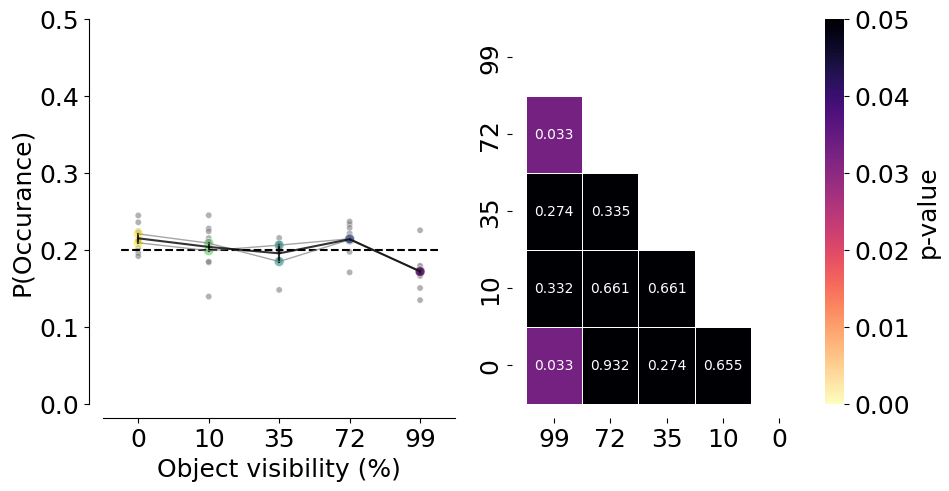

In [8]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts["aperture"] = counts["aperture"].astype("float")
counts = counts.sort_values("aperture")

counts["aperture_numeric"] = counts["aperture"]
aperture_order = counts["aperture"].unique()
counts["aperture"] = pd.Categorical(counts["aperture"].astype("str"), categories=aperture_order.astype("str"), ordered=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
    ax=ax[0]
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    palette=plotting.colors_multi_aperture[::-1],
    alpha=0.6,
    s=50,
    zorder=2,
    ax=ax[0]
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
    ax=ax[0]
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
    ax=ax[0]
)

ax[0].hlines(
    0.2,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, .5)
ax[0].set_xlim(-0.5, 4.5)
ax[0].invert_xaxis()

ax[0].set_xticks([4, 3, 2, 1, 0], ["0", "10", "35", "72", "99"])

ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("P(Occurance)")
sns.despine(offset=10)
ax[0].legend([], [], frameon=False)

# Use numeric aperture for statistical analysis
counts_for_stats = counts.copy()
counts_for_stats['aperture'] = counts_for_stats['aperture_numeric']
p_values = get_multi_p_values_global(counts_for_stats,  y_var="probability")
plot_aperture_heatmap(p_values, ax= ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

print(AnovaRM(counts_for_stats, depvar="probability", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_occurance.svg", transparent=True)

3.0-4.2: TtestResult(statistic=-2.3392630487026396, pvalue=0.05190124008981912, df=7)
3.0-6.0: TtestResult(statistic=-6.08774257155369, pvalue=0.0004970537208635454, df=7)
3.0-8.48: TtestResult(statistic=-6.30435503646218, pvalue=0.00040247516431621695, df=7)
3.0: mean=0.605 ± 0.019
4.2-6.0: TtestResult(statistic=-1.5972841146255685, pvalue=0.1542339106806559, df=7)
4.2-8.48: TtestResult(statistic=-1.5522269454651254, pvalue=0.16454917734195743, df=7)
4.2: mean=0.707 ± 0.045
6.0-8.48: TtestResult(statistic=-0.15686023101516638, pvalue=0.8797833917428446, df=7)
6.0: mean=0.798 ± 0.029
8.48: mean=0.806 ± 0.030
12.0-3.0: TtestResult(statistic=16.180440467573828, pvalue=8.378804002495314e-07, df=7)
12.0-4.2: TtestResult(statistic=2.529808486595765, pvalue=0.03924392677256261, df=7)
12.0-6.0: TtestResult(statistic=0.5849702281581031, pvalue=0.5769289283915142, df=7)
12.0-8.48: TtestResult(statistic=0.2809816312620083, pvalue=0.7868483140103282, df=7)
12.0: mean=0.816 ± 0.016
               

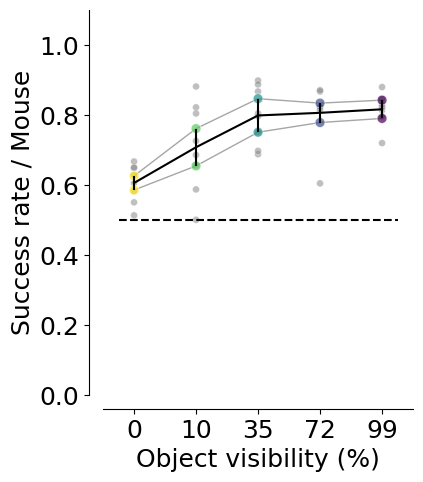

In [9]:
# Success rate per mouse
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax.set_ylim(0, 1.1)
ax.set_xlim(-0.5, 4.5)
ax.set_xlabel("Object visibility (%)")
ax.set_ylabel("Success rate / Mouse")
ax.set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax.legend([], [], frameon=False)
sns.despine(offset=10)

print(AnovaRM(counts_for_stats, depvar="probability", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_rewards_per_mouse.svg", transparent=True)

3.0-4.2: TtestResult(statistic=-2.4453623165763343, pvalue=0.04440827729882122, df=7)
3.0-6.0: TtestResult(statistic=-6.732729969901468, pvalue=0.00026923129860644224, df=7)
3.0-8.48: TtestResult(statistic=-5.057029440050966, pvalue=0.0014682231255013492, df=7)
3.0: mean=0.605 ± 0.019
4.2-6.0: TtestResult(statistic=-3.168173935827564, pvalue=0.015747861222635988, df=7)
4.2-8.48: TtestResult(statistic=-3.029498103858448, pvalue=0.019128136923207906, df=7)
4.2: mean=0.707 ± 0.045
6.0-8.48: TtestResult(statistic=-0.2968184770799302, pvalue=0.7752189803790304, df=7)
6.0: mean=0.798 ± 0.029
8.48: mean=0.806 ± 0.030
12.0-3.0: TtestResult(statistic=13.820397713702063, pvalue=2.451783852206455e-06, df=7)
12.0-4.2: TtestResult(statistic=2.7622591414536393, pvalue=0.02800465906012416, df=7)
12.0-6.0: TtestResult(statistic=0.8337967235485317, pvalue=0.43192388189880637, df=7)
12.0-8.48: TtestResult(statistic=0.30048262919977825, pvalue=0.7725369758633158, df=7)
12.0: mean=0.816 ± 0.016
          

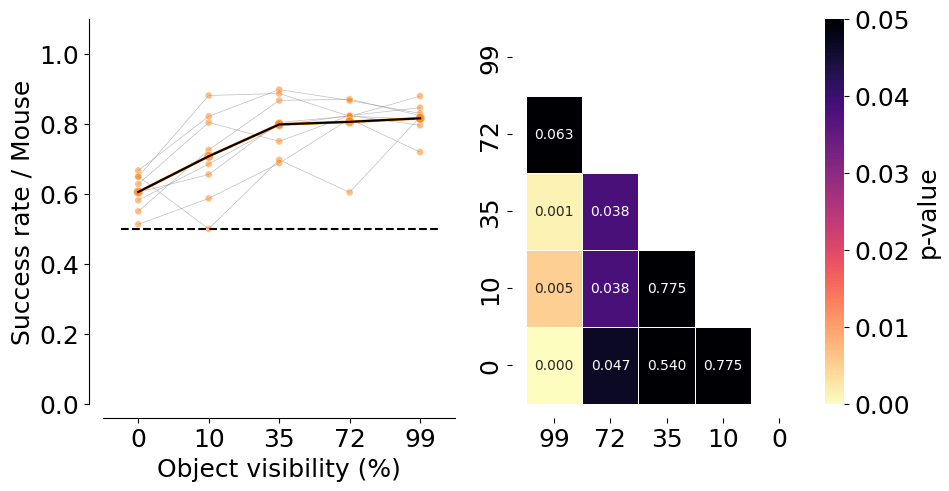

In [10]:
# Success rate per mouse
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[0].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, 1.1)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("Success rate / Mouse")
ax[0].set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_p_values_global(trial_df, y_var="trial_rewarded")
plot_aperture_heatmap(p_values, ax=ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_rewarded", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_rewards.svg", transparent=True)

3.0-4.2: TtestResult(statistic=0.14871936232443542, pvalue=0.885968776646409, df=7)
3.0-6.0: TtestResult(statistic=-0.36441634266169565, pvalue=0.7263066670496003, df=7)
3.0-8.48: TtestResult(statistic=-1.0687186436975773, pvalue=0.320659343125768, df=7)
3.0: mean=-0.323 ± 0.073
4.2-6.0: TtestResult(statistic=-0.34305952711447474, pvalue=0.7416256805847223, df=7)
4.2-8.48: TtestResult(statistic=-0.9437473085470102, pvalue=0.3767234096340823, df=7)
4.2: mean=-0.339 ± 0.076
6.0-8.48: TtestResult(statistic=-0.2252588308666003, pvalue=0.8282128711831594, df=7)
6.0: mean=-0.283 ± 0.098
8.48: mean=-0.259 ± 0.042
12.0-3.0: TtestResult(statistic=-0.5733972297440026, pvalue=0.5843183382852799, df=7)
12.0-4.2: TtestResult(statistic=-0.24853980914924145, pvalue=0.810850857961489, df=7)
12.0-6.0: TtestResult(statistic=-0.9982893998528993, pvalue=0.351389402376994, df=7)
12.0-8.48: TtestResult(statistic=-2.2793051425585507, pvalue=0.0566943145801148, df=7)
12.0: mean=-0.365 ± 0.054
3.0-4.2: TtestRe

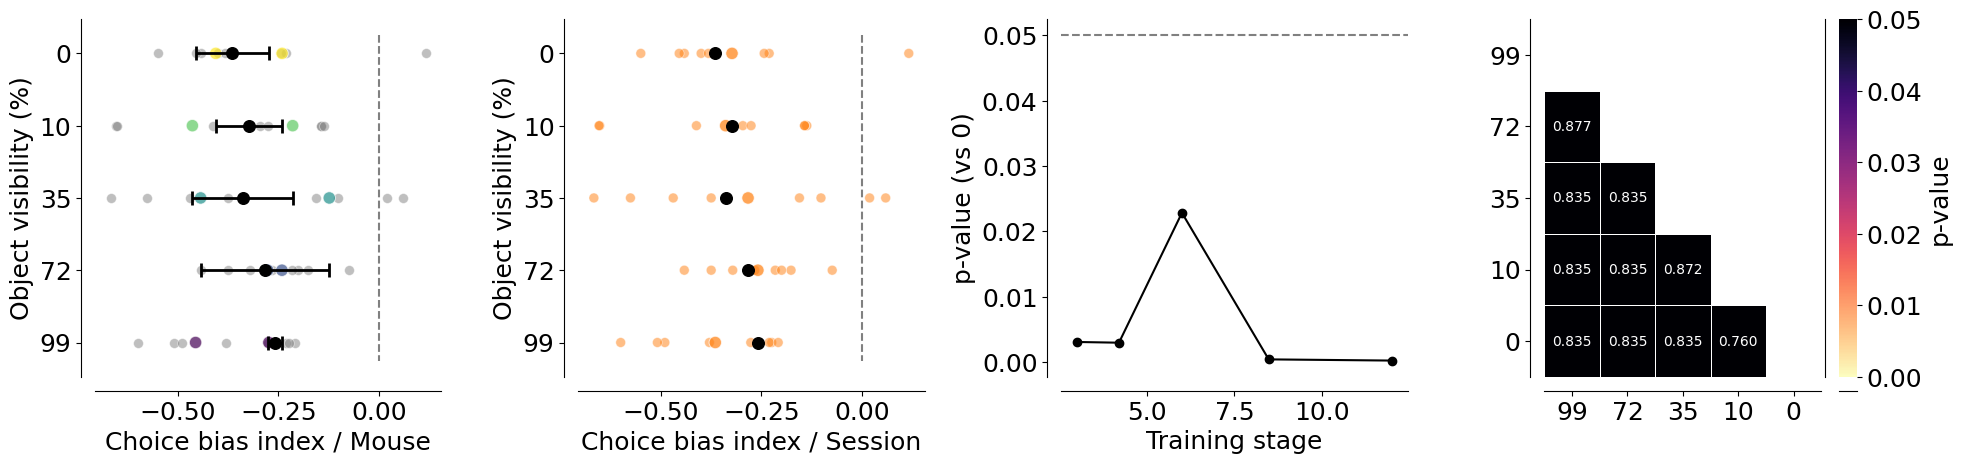

In [11]:
trial_df["trial_bias"] = 2 * trial_df["trial_left_choice"] - 1 

# Choice bias per mouse and per lab
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    plot_bias=True,
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax[0].vlines(
    0,
    ymin=-0.25,
    ymax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="grey",
)

ax[0].set_ylabel("Object visibility (%)")
ax[0].set_xlabel("Choice bias index / Mouse")
ax[0].set_yticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    ax=ax[1],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[1].vlines(
    0,
    ymin=-0.25,
    ymax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="grey",
)

ax[1].set_ylabel("Object visibility (%)")
ax[1].set_xlabel("Choice bias index / Session")
ax[1].set_yticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[1].legend([], [], frameon=False)

# One-sample t-test of bias against 0 (null) across session
apertures_ = []
for stage in sorted(trial_df.aperture.unique()):
    #vals = trial_df.groupby("dataset").mean().loc[trial_df.aperture == stage, "trial_bias"]
    vals = trial_df[trial_df.aperture == stage].groupby("dataset")["trial_bias"].mean()
    t_stat, p_val = stats.ttest_1samp(vals, 0)
    apertures_.append({
        "aperture": stage,
        "n": len(vals),
        "mean_bias": vals.mean(),
        "t_stat": t_stat,
        "df": max(len(vals) - 1, 0),
        "p_value": p_val,
    })
apertures_df = pd.DataFrame(apertures_)
print("One-sample t-tests vs 0 (bias)")
print(apertures_df)

# Plot p-values only (no bar/box)
ax[2].plot(apertures_df["aperture"], apertures_df["p_value"], 
           marker="o", linestyle="-", color="k")
ax[2].axhline(0.05, color="grey", linestyle="--")
ax[2].set_xlabel("Training stage")
ax[2].set_ylabel("p-value (vs 0)")

# Plot p-values of the multi-comparison test
p_values = get_multi_p_values_global(trial_df, y_var="trial_bias")
plot_aperture_heatmap(p_values, ax=ax[3])
ax[3].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[3].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_bias", subject="dataset", within=["aperture"]).fit())

sns.despine(offset=10)
plt.tight_layout(pad=2)

plt.savefig(save_fig_path + "figure5_choice_bias.svg", transparent=True)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  8.2385 4.0000 28.0000 0.0002



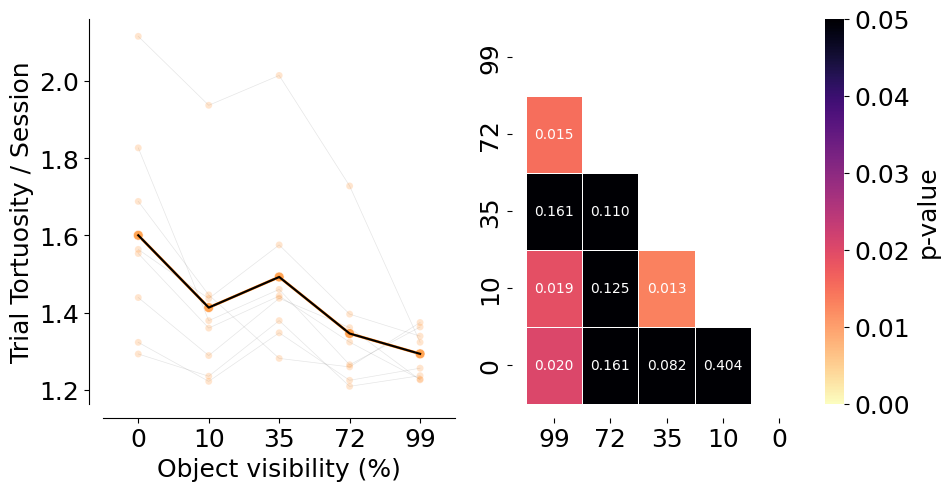

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

counts = (
    trial_df
    .groupby(["lab_id", "dataset", "aperture"], as_index=False)
    .trial_tortuosity.mean()
)

counts["count"] = counts["trial_tortuosity"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_lab=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[0].invert_xaxis()

ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("Trial Tortuosity / Session")
ax[0].set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_p_values_global(trial_df,  y_var="trial_tortuosity")
plot_aperture_heatmap(p_values, ax=ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_tortuosity", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure5_tortuosity.svg", transparent=True)

## Trajectory analysis

In [13]:
xy_df = []
for m in sessions_list:
    xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
xy_df = pd.concat(xy_df)
xy_df["mouse_name"] = xy_df.dataset.str.split("_").str [0]

/tmp/ipykernel_4361/1758988696.py:3: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
/tmp/ipykernel_4361/1758988696.py:3: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
/tmp/ipykernel_4361/1758988696.py:3: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
/tmp/ipykernel_4361/1758988696.py:3: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0

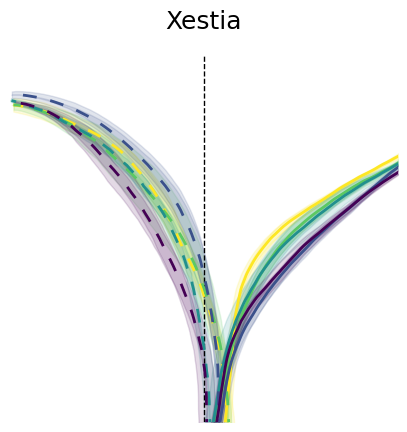

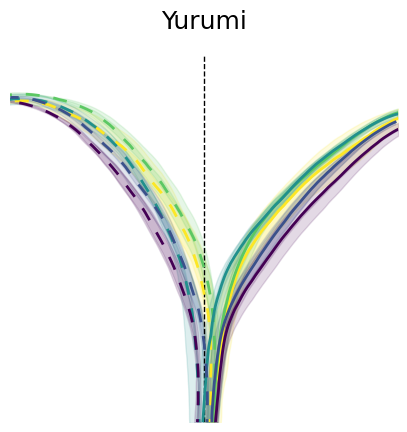

In [14]:
# Mean and error by mouse
mean_mouse = analysis.mean_xy_trajectory(xy_df,
                                         index_columns=[
                                             "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

for m in mean_mouse.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse[mean_mouse.mouse_name == m], cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")
    plt.title(m)
    plt.savefig(save_fig_path + f"figure5_trajectories_time_{m}.svg", transparent=True)
    plt.savefig(save_fig_path + f"figure5_trajectories_time_{m}.png", transparent=True, dpi=300)

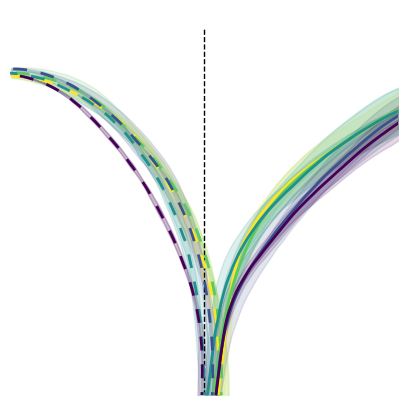

In [15]:
# Mean and error by aperture and choice
mean_group = analysis.mean_xy_trajectory(mean_mouse, 
                                         index_columns=[
                                             "aperture",  "trial_left_choice", "trial_length"
                                         ])

# Plot the mean trajectories from 0, 23 cm in y axis, -18, 18 cm in x axis, colored by choice and styled by aperture
plotting.plot_mean_xy_trajectory(mean_group, cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")

plt.savefig(save_fig_path + "figure5_trajectories_time.svg", transparent=True)
plt.savefig(save_fig_path + "figure5_trajectories_time.png", transparent=True, dpi=300)

## Stats on trajectories

In [16]:
y_binned_df = []
for m in sessions_list:
    try:
        y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "trial_left_choice", "x", "y", "flip_one_side", "trial_rewarded", "velocity", "trial_length", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df = pd.concat(y_binned_df)

/tmp/ipykernel_4361/972093021.py:4: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "trial_left_choice", "x", "y", "flip_one_side", "trial_rewarded", "velocity", "trial_length", as_dict=True)[0]))
/tmp/ipykernel_4361/972093021.py:4: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "trial_left_choice", "x", "y", "flip_one_side", "trial_rewarded", "velocity", "trial_length", as_dict=True)[0]))
/tmp/ipykernel_4361/972093021.py:4: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"')

In [17]:
aperture_to_occlusion = {
    12.0: 99,
    8.48: 72,
    6.0: 35,
    4.2: 10,
    3.0: 0
}

y_binned_df["aperture"] = y_binned_df["aperture"].map(aperture_to_occlusion)
y_binned_df["mouse_name"] = y_binned_df.dataset.str.split("_").str [0]
y_binned_df["x_flipped"] = y_binned_df.x * y_binned_df.flip_one_side
data = utils.create_bins(y_binned_df)
y_binned_df_mean = analysis.mean_xy_trajectory(data, index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])

                       Anova
                     F Value  Num DF  Den DF  Pr > F
----------------------------------------------------
aperture              2.6413  4.0000  28.0000 0.0547
bin_centers          98.8025 24.0000 168.0000 0.0000
aperture:bin_centers  1.0258 96.0000 672.0000 0.4191



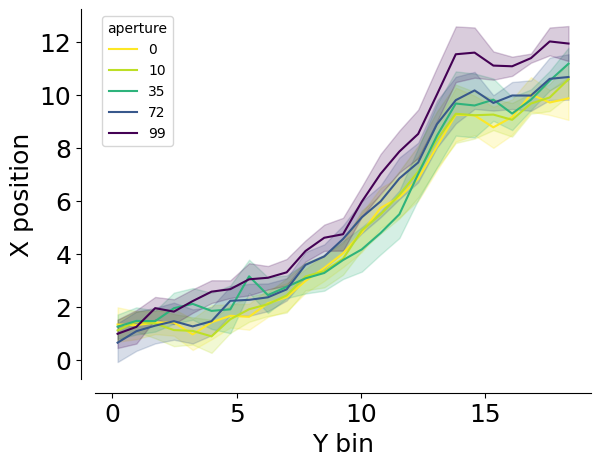

In [18]:
# NOTE(celia): Data unbalanced across bins, so only include bins so that balanced
stats_binned = y_binned_df_mean[(y_binned_df_mean.bin_centers >= 0) & (y_binned_df_mean.bin_centers <= 19)]

sns.lineplot(data=stats_binned, x="bin_centers", y="x_flipped", hue="aperture", palette= "viridis_r",errorbar="se")
plt.xlabel("Y bin")
plt.ylabel("X position")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure5_mean_xy_trajectory.svg")

print(
    AnovaRM(
        data=stats_binned,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

In [19]:
p_value_df = get_multi_p_values_binned(stats_binned, x_var="bin_centers", y_var="x_flipped")

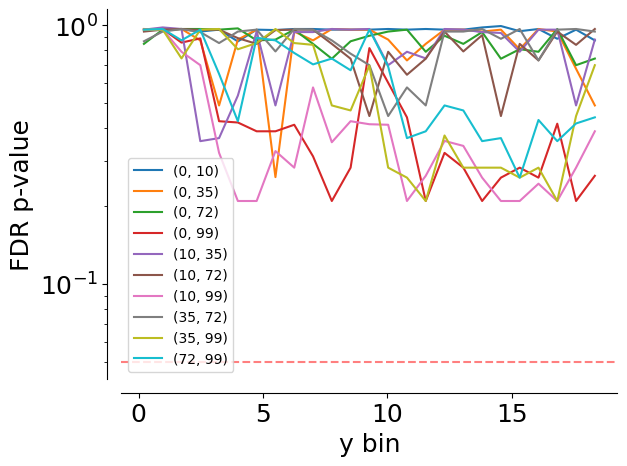

In [20]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.comp1, p_value_df.comp2))
plt.ylabel("FDR p-value")
plt.xlabel("y bin")
plt.yscale("log")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure5_pos_pvalue.svg", transparent=True)

In [21]:
p_value_df.pivot(index = "bin", columns=["comp1", "comp2"], values=["p_value_corr"])

p_value_corr                                                    \
comp1             0                                       10             
comp2             10        35        72        99        35        72   
bin                                                                      
0.2145      0.962250  0.967908  0.847888  0.962250  0.962250  0.946026   
0.9695      0.962250  0.962250  0.962250  0.967908  0.981444  0.962250   
1.7245      0.967908  0.967908  0.967908  0.857516  0.967908  0.967908   
2.4795      0.946026  0.874526  0.967908  0.890295  0.356836  0.958815   
3.2345      0.962250  0.490108  0.962250  0.426072  0.366614  0.962250   
3.9895      0.866506  0.880795  0.973218  0.421265  0.535024  0.892152   
4.7445      0.962250  0.962250  0.874526  0.389535  0.946026  0.847888   
5.5000      0.958815  0.259146  0.880795  0.389535  0.490304  0.958815   
6.2555      0.967908  0.946026  0.962250  0.412847  0.941595  0.962250   
7.0105      0.967908  0.874526  0.847888  0.311714  0.941595  0.962250   
7.7655      0.962250  0.967908  0.742966  0.209507  0.967908  0.847888   
8.5205      0.962250  0.962250  0.867698  0.281853  0.962250  0.742966   
9.2755      0.962250  0.962250  0.911362  0.816533  0.967908  0.446106   
10.0305     0.967908  0.880795  0.946026  0.599887  0.701391  0.790342   
10.7855     0.962250  0.731761  0.962250  0.441000  0.790342  0.644200   
11.5405     0.967908  0.847888  0.790342  0.209507  0.745041  0.742966   
12.2955     0.962250  0.962250  0.911362  0.321534  0.967908  0.946026   
13.0510     0.962250  0.962250  0.847888  0.281853  0.962250  0.792701   
13.8065     0.981444  0.946026  0.941595  0.209507  0.941595  0.916290   
14.5615     0.993719  0.962250  0.742966  0.257909  0.934317  0.446106   
15.3165     0.949079  0.808078  0.808814  0.281853  0.790342  0.847888   
16.0715     0.967908  0.967908  0.790342  0.257909  0.962250  0.731761   
16.8265     0.887168  0.946026  0.967908  0.416750  0.962250  0.946026   
17.5815     0.962250  0.679313  0.701391  0.209507  0.490304  0.840531   
18.3365     0.874526  0.490304  0.743968  0.262178  0.880795  0.967908   

                                                 
comp1                    35                  72  
comp2          99        72        99        99  
bin                                              
0.2145   0.962250  0.867698  0.962250  0.962250  
0.9695   0.962250  0.946026  0.962250  0.967908  
1.7245   0.790342  0.966708  0.745041  0.875275  
2.4795   0.701391  0.941595  0.962250  0.962250  
3.2345   0.321534  0.854062  0.967908  0.649173  
3.9895   0.209507  0.946026  0.808078  0.426072  
4.7445   0.209507  0.962250  0.854062  0.895413  
5.5000   0.326671  0.792701  0.967908  0.874526  
6.2555   0.281853  0.967908  0.854062  0.781912  
7.0105   0.575506  0.962250  0.840531  0.706401  
7.7655   0.353365  0.874526  0.490304  0.743968  
8.5205   0.426072  0.777146  0.468899  0.670359  
9.2755   0.414798  0.701391  0.698371  0.962250  
10.0305  0.412847  0.446106  0.281853  0.692373  
10.7855  0.209507  0.575506  0.257909  0.366614  
11.5405  0.262178  0.490304  0.209507  0.389535  
12.2955  0.357543  0.946026  0.375252  0.490304  
13.0510  0.342083  0.946026  0.281853  0.468899  
13.8065  0.257909  0.967908  0.281853  0.356909  
14.5615  0.209507  0.886911  0.281853  0.366614  
15.3165  0.209507  0.967908  0.257909  0.257909  
16.0715  0.244386  0.731761  0.281853  0.430796  
16.8265  0.209507  0.962250  0.209507  0.356836  
17.5815  0.281853  0.967908  0.446106  0.417624  
18.3365  0.389535  0.946026  0.701391  0.441000

## Velocity analysis

In [22]:
velocity_df = []
for m in sessions_list:
    #print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

mean_mouse = velocity_df.groupby(["dataset", "aperture", "trial_length"],as_index=False).mean()

/tmp/ipykernel_4361/1590699916.py:4: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
/tmp/ipykernel_4361/1590699916.py:4: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
/tmp/ipykernel_4361/1590699916.py:4: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
/tmp/ipykernel_4361/1590699916.py:4: DeprecationWarning: fetch() is deprecated in DataJoint 2.0. Use to_dicts(), to_pandas(), to_arrays(), or keys() instead.
  velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch

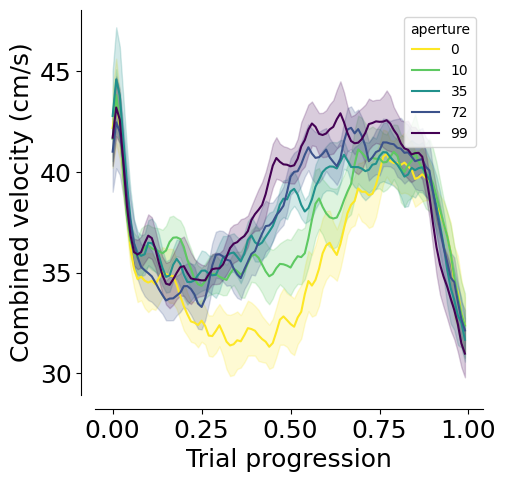

In [23]:
aperture_to_occlusion = {
    12.0: 99,
    8.48: 72,
    6.0: 35,
    4.2: 10,
    3.0: 0
}

# Map the values
mean_mouse['aperture'] = mean_mouse['aperture'].map(aperture_to_occlusion)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.lineplot(
    data=mean_mouse,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_multi_aperture,
    hue="aperture",
    errorbar="se",
    ax=ax,
)

sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.savefig(save_fig_path + "figure5_velocity.svg", transparent=True)

In [24]:
print(
    AnovaRM(
        data=mean_mouse,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                         Anova
                      F Value  Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture               4.4533   4.0000   28.0000 0.0065
trial_length          20.4192  99.0000  693.0000 0.0000
aperture:trial_length  3.7376 396.0000 2772.0000 0.0000



In [25]:
p_value_df = get_multi_p_values_binned(mean_mouse, x_var="trial_length", y_var="velocity")

In [26]:
p_value_df

,bin,comp1,comp2,p_value,p_value_corr
0,0.00,0,10,0.697735,0.886267
0,0.00,0,35,0.753826,0.909012
0,0.00,0,72,0.251758,0.575260
0,0.00,0,99,0.648149,0.866510
0,0.00,10,35,0.557152,0.813145
...,...,...,...,...,...
0,0.99,10,72,0.763189,0.915095
0,0.99,10,99,0.142521,0.419078
0,0.99,35,72,0.520277,0.801859
0,0.99,35,99,0.394578,0.709672


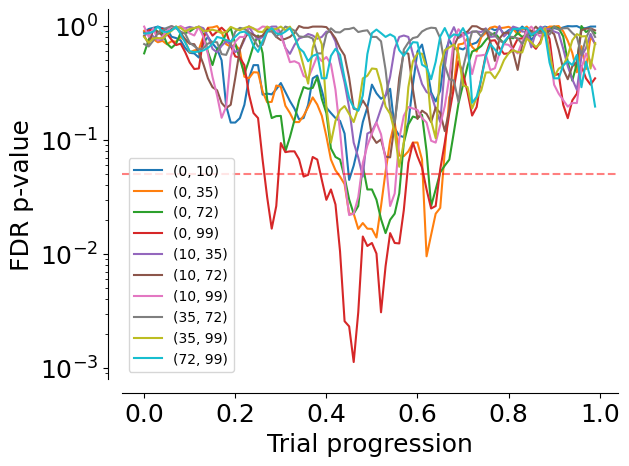

In [27]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.comp1, p_value_df.comp2))
plt.ylabel("FDR p-value")
plt.xlabel("Trial progression")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure5_velocity_pvalue.svg", transparent=True)